                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
(50000, 2)

LOGISTIC REGRESSION
Accuracy: 0.8838
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.87      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


LINEAR SVM (BEST MODEL)
Accuracy: 0.8738
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      4961
           1       0.87      0.89      0.88      5039

    accuracy                           0

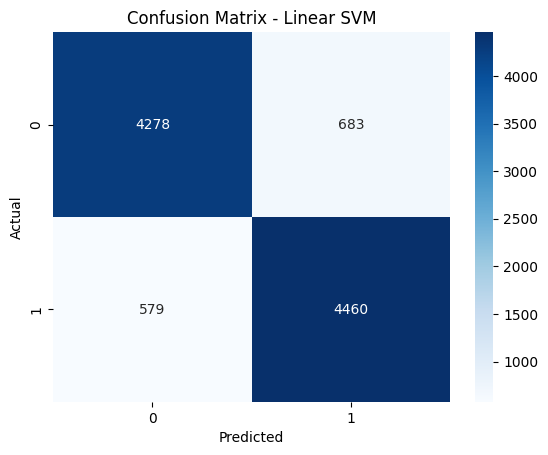

In [2]:
# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np

import re
import string

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score

# =====================================================
# 2. LOAD DATASET
# =====================================================

df = pd.read_csv("/content/IMDB Dataset.csv")

print(df.head())
print(df.shape)

# =====================================================
# 3. LABEL ENCODING
# =====================================================

df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# =====================================================
# 4. TEXT CLEANING
# =====================================================

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    return text

df['review'] = df['review'].apply(clean_text)

# =====================================================
# 5. FEATURES & TARGET
# =====================================================

X = df['review']
y = df['sentiment']

# =====================================================
# 6. TF-IDF VECTORISATION
# =====================================================

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(X)

# =====================================================
# 7. TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# 8. MODEL 1 - LOGISTIC REGRESSION
# =====================================================

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\nLOGISTIC REGRESSION")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

# =====================================================
# 9. MODEL 2 - LINEAR SVM (BEST MODEL)
# =====================================================

svm = LinearSVC()
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("\nLINEAR SVM (BEST MODEL)")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

# =====================================================
# 10. MODEL 3 - NAIVE BAYES
# =====================================================

nb = MultinomialNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("\nNAIVE BAYES")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

# =====================================================
# 11. MODEL COMPARISON
# =====================================================

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, nb_pred)
    ]
})

print("\nMODEL COMPARISON")
print(results.sort_values(by="Accuracy", ascending=False))

# =====================================================
# 12. CONFUSION MATRIX (BEST MODEL = SVM)
# =====================================================

cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

because Linear SVM (Support Vector Machine) is often a strong choice for classification problems, especially when:

The target variable is categorical (0/1, Yes/No, Spam/Not Spam, etc.).
There are many features.
The classes are approximately linearly separable.
You want good accuracy with relatively fast training.
